In [2]:
!pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable
  Using cached mysql_connector_python-9.6.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
Using cached mysql_connector_python-9.6.0-cp313-cp313-win_amd64.whl (16.5 MB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\tabis\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import mysql.connector

In [3]:
connect = mysql.connector.connect(
host = 'localhost',
user = 'root',
password = 'Otuo@2024',
database = 'personal_projects'
)

In [4]:
query = 'SELECT * FROM personal_projects.bank_info'

In [5]:
df = pd.read_sql(query,connect)

C:\Users\tabis\AppData\Local\Temp\ipykernel_27560\4197096623.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,connect)


In [6]:
df.describe() # Display summary statistics for the DataFrame

,CustomerId,Age,NumOfProducts,Tenure,CreditScore
count,9.997000e+03,9997.000000,9997.000000,9997.000000,9997.000000
mean,1.569094e+07,38.923477,1.530359,5.013004,650.528058
std,7.193391e+04,10.488549,0.581669,2.892504,96.648090
min,1.556570e+07,18.000000,1.000000,0.000000,350.000000
25%,1.562856e+07,32.000000,1.000000,3.000000,584.000000
50%,1.569073e+07,37.000000,1.000000,5.000000,652.000000
75%,1.575323e+07,44.000000,2.000000,7.000000,718.000000
max,1.581569e+07,92.000000,4.000000,10.000000,850.000000


In [7]:
# Feature Engineering
# Create age groups based on the Age column
Condition = [
    df['Age'] <= 35,
    df['Age'] <= 55,
    df['Age'] > 55
]

Choices = ['Young', 'Middle-aged', 'Older Adults']
df['Age_Group'] = np.select(Condition, Choices, default = 'Other')
df.head(10)

,CustomerId,Age,Gender,Geography,IsActiveMember,HasCrCard,NumOfProducts,Exited,Tenure,CreditScore,EstimatedSalary,Balance,Age_Group
0,15634602,42,Female,France,Yes,Yes,1,1,2,619,"101,348.88",0.0,Middle-aged
1,15634602,42,Female,France,Yes,Yes,1,1,2,619,"101,348.88",0.0,Middle-aged
2,15647311,41,Female,Spain,Yes,Yes,1,0,1,608,"112,542.58",83807.86,Middle-aged
3,15619304,42,Female,France,No,No,3,1,8,502,"113,931.57",159660.8,Middle-aged
4,15701354,39,Female,France,No,No,2,0,1,699,"93,826.63",0.0,Middle-aged
5,15737888,43,Female,Spain,Yes,Yes,1,0,2,850,"79,084.10",125510.82,Middle-aged
6,15574012,44,Male,Spain,No,No,2,1,8,645,"149,756.71",113755.78,Middle-aged
7,15592531,50,Male,France,Yes,Yes,2,0,7,822,"10,062.80",0.0,Middle-aged
8,15656148,29,Female,Germany,No,No,4,1,4,376,"119,346.88",115046.74,Young
9,15792365,44,Male,France,Yes,Yes,2,0,4,501,"74,940.50",142051.07,Middle-aged


In [8]:
df.head()

,CustomerId,Age,Gender,Geography,IsActiveMember,HasCrCard,NumOfProducts,Exited,Tenure,CreditScore,EstimatedSalary,Balance,Age_Group
0,15634602,42,Female,France,Yes,Yes,1,1,2,619,"101,348.88",0.0,Middle-aged
1,15634602,42,Female,France,Yes,Yes,1,1,2,619,"101,348.88",0.0,Middle-aged
2,15647311,41,Female,Spain,Yes,Yes,1,0,1,608,"112,542.58",83807.86,Middle-aged
3,15619304,42,Female,France,No,No,3,1,8,502,"113,931.57",159660.8,Middle-aged
4,15701354,39,Female,France,No,No,2,0,1,699,"93,826.63",0.0,Middle-aged


In [9]:
df['Exited'] = df['Exited'].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerId       9997 non-null   int64
 1   Age              9997 non-null   int64
 2   Gender           9997 non-null   str  
 3   Geography        9997 non-null   str  
 4   IsActiveMember   9997 non-null   str  
 5   HasCrCard        9997 non-null   str  
 6   NumOfProducts    9997 non-null   int64
 7   Exited           9997 non-null   int64
 8   Tenure           9997 non-null   int64
 9   CreditScore      9997 non-null   int64
 10  EstimatedSalary  9997 non-null   str  
 11  Balance          9997 non-null   str  
 12  Age_Group        9997 non-null   str  
dtypes: int64(6), str(7)
memory usage: 1015.4 KB


In [10]:
df['Status'] = np.where(df['Exited'] == 1, 'Churned', 'Not Churned')

In [11]:
df['EstimatedSalary'] = df['EstimatedSalary'].str.replace(',', '').astype(float)

In [12]:
df.info()
df['Balance'] = df['Balance'].astype(float)

<class 'pandas.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       9997 non-null   int64  
 1   Age              9997 non-null   int64  
 2   Gender           9997 non-null   str    
 3   Geography        9997 non-null   str    
 4   IsActiveMember   9997 non-null   str    
 5   HasCrCard        9997 non-null   str    
 6   NumOfProducts    9997 non-null   int64  
 7   Exited           9997 non-null   int64  
 8   Tenure           9997 non-null   int64  
 9   CreditScore      9997 non-null   int64  
 10  EstimatedSalary  9997 non-null   float64
 11  Balance          9997 non-null   str    
 12  Age_Group        9997 non-null   str    
 13  Status           9997 non-null   str    
dtypes: float64(1), int64(6), str(7)
memory usage: 1.1 MB


In [13]:
# Exploratory Data Analysis
(df.groupby('Status').agg(Count=('Status', 'count'), 
    Average_Balance=('Balance', 'mean'), 
    Average_Salary=('EstimatedSalary', 'mean'),
    average_credit_score=('CreditScore', 'mean'))
    .round(2)
)

,Count,Average_Balance,Average_Salary,average_credit_score
Status,,,,
Churned,2038,91063.83,101465.62,645.34
Not Churned,7959,72732.64,99748.48,651.86


In [ ]:
# Pivot Table to count CustomerIds by Status and activity
df.pivot_table(
    index='Status',
    columns='IsActiveMember',
    values='CustomerId',
    aggfunc='count'
)

IsActiveMember,No,Yes
Status,,
Churned,1302,736
Not Churned,3545,4414


In [ ]:
# Pivot Table to count CustomerIds by Status and Gender
df.pivot_table(
    index='Status',
    columns='Gender',
    values='CustomerId',
    aggfunc='count'
)

Gender,Female,Male
Status,,
Churned,1140,898
Not Churned,3401,4558


In [ ]:
# Pivot Table to count CustomerIds by Status and Geography
df.pivot_table(
    index='Status',
    columns='Geography',
    values='CustomerId',
    aggfunc='count'
)

Geography,France,Germany,Spain
Status,,,
Churned,811,814,413
Not Churned,4202,1694,2063


In [ ]:
# Pivot Table to count CustomerIds by Status and Has a Credit Card
df.pivot_table(
    index='Status',
    columns='HasCrCard',
    values='CustomerId',
    aggfunc='count'
)

HasCrCard,No,Yes
Status,,
Churned,1302,736
Not Churned,3545,4414


In [ ]:
# Pivot Table to count CustomerIds by Status and Number Of Products
df.pivot_table(
    index='Status',
    columns='NumOfProducts',
    values='CustomerId',
    aggfunc='count'
).fillna(0).astype(int)

NumOfProducts,1,2,3,4
Status,,,,
Churned,1410,348,220,60
Not Churned,3671,4242,46,0


In [31]:
import seaborn as sns 

<Axes: >

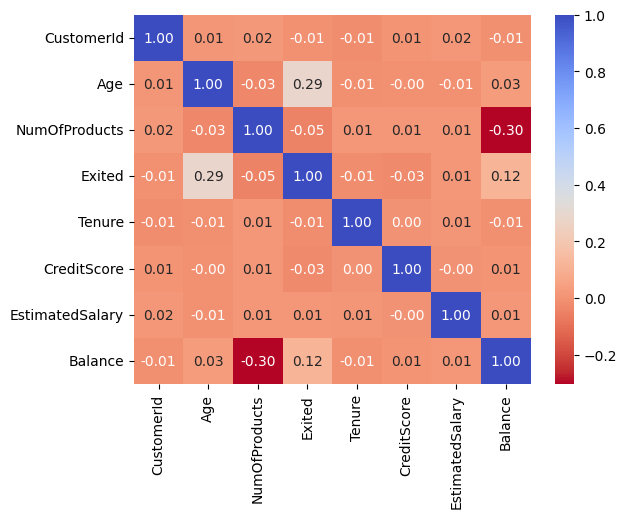

In [ ]:
# Correlation Analysis 
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm_r")

In [ ]:
# Export the cleaned and analyzed DataFrame to a CSV file
df.to_csv("bank_analysis.csv", index=False)